In [85]:
# PCA on doiabetes dataset 
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import numpy as np
import matplotlib.pyplot as plt

In [86]:
df=pd.read_csv('diabetes.csv')


In [87]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [88]:
numerical_cols=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
# Hamndle missing values for numrical columns
numerical_data=df[numerical_cols]
impure_num=SimpleImputer(strategy='mean')
numerical_data=impure_num.fit_transform(numerical_data)
numerical_df=pd.DataFrame(numerical_data,columns=numerical_cols)

In [89]:
#Stdanadrise the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numerical_df)

In [90]:
#Apply PCA
pca = PCA()
X_pca = pca.fit_transform(data_scaled)


In [91]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

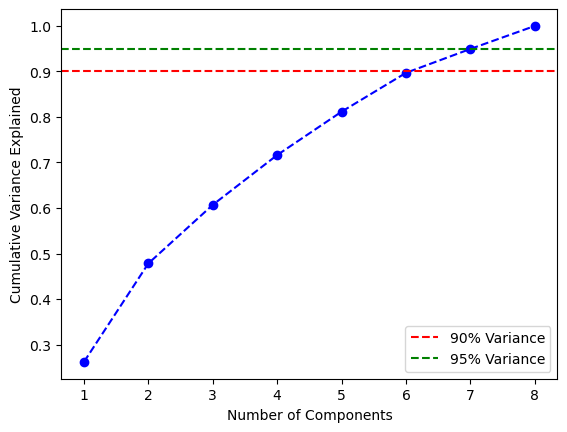

In [92]:
#Plot cumulative variance
plt.Figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker='o',linestyle='--',color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.9,color='r',linestyle = '--',label = '90% Variance')
plt.axhline(y=0.95,color='g',linestyle = '--',label = '95% Variance')
plt.legend()

In [93]:
#Display PCA results
print('Explained VAriance Ratio (for each PC):')
print(explained_variance)
print('\nCumulative VAriance:')
print(cumulative_variance)


Explained VAriance Ratio (for each PC):
[0.26179749 0.21640127 0.12870373 0.10944113 0.09529305 0.08532855
 0.05247702 0.05055776]

Cumulative VAriance:
[0.26179749 0.47819876 0.60690249 0.71634362 0.81163667 0.89696522
 0.94944224 1.        ]


In [94]:
#show composition (loading) of each Principle Component
loadings = pd.DataFrame(
    pca.components_,
    columns=numerical_cols,
    index=[f'PC{i+1}' for i in range (len(numerical_cols))]
) 
loadings

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
PC1,0.128432,0.393083,0.360003,0.439824,0.435026,0.451941,0.270611,0.198027
PC2,0.593786,0.174029,0.183892,-0.331965,-0.250781,-0.100960,-0.122069,0.620589
PC3,0.013087,-0.467923,0.535494,0.237674,-0.336709,0.361865,-0.433189,-0.075248
PC4,0.080691,-0.404329,0.055986,0.037976,-0.349944,0.053646,0.833680,0.071201
PC5,0.475606,-0.466328,-0.327953,0.487862,0.346935,-0.253204,-0.119810,0.109290
PC6,0.193598,0.094162,-0.634116,0.009589,-0.270651,0.685372,-0.085784,-0.033357
PC7,-0.588790,-0.060153,-0.192118,0.282213,-0.132010,-0.035366,-0.086091,0.712085
PC8,0.117841,0.450355,-0.011296,0.566284,-0.548621,-0.341518,-0.008259,-0.211662


In [106]:
#Select first three principal components
X_selected = X_pca[:,:4]
y = df['Outcome']

In [107]:
#Split the data into trainig and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y , test_size=0.2, random_state=42)

In [108]:
#Train a Logistic Regression Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train,y_train)
y_pred = log_reg.predict(X_test)

In [105]:
accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)
report = classification_report(y_test,y_pred)
print(f'Accuracy:{accuracy:2f}')
print(conf_matrix)
print(report)

Accuracy:0.727273
[[82 17]
 [25 30]]
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.64      0.55      0.59        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154

